In [1]:
import numpy as np
import pandas as pd
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split
import shap
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [3]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 5, 6, 7, 8, 9, 10, 
years: 2011, 2012, 2013, 2014, 2018, 2019, 2020, 2021, 


In [4]:
r_u = 0
near_u = 0
smote = 0
scaler = 'minmax'
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,26,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,12.5,15.7,0.0,1,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,49,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,11.8,15.9,0.0,1,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,23,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,15.0,18.5,0.0,1,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,43,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,10.8,16.1,0.0,1,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,5,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,9.0,16.1,0.0,1,0,0


In [6]:
dataset = dataset.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [7]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,792,0,792,8.24%
1,2011,771,30,801,8.34%
2,2012,771,44,815,8.48%
3,2013,764,35,799,8.32%
4,2014,790,2,792,8.24%
5,2015,792,0,792,8.24%
6,2016,792,0,792,8.24%
7,2017,792,0,792,8.24%
8,2018,712,138,850,8.85%
9,2019,777,23,800,8.33%


In [8]:
X_train = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_train = dataset['case']

features = X_train.columns

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

imputer = KNNImputer()
X_train = imputer.fit_transform(X_train)

try:
    class_0_counts = y_train.value_counts()[0]
except KeyError:
    class_0_counts = 0
try:
    class_1_counts = y_train.value_counts()[1]
except KeyError:
    class_1_counts = 0
        
if (near_u != 0):
    nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    X_train, y_train = nm.fit_resample(X_train, y_train)
    
if (smote != 0):
    class_0_counts = y_train.value_counts()[0]
    sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    X_train, y_train = sm.fit_resample(X_train, y_train)

w0,w1 = calculate_weights(y_train)

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
model.fit(X_train, y_train)

masker = shap.maskers.Independent(data = X_train)
explainer = shap.LinearExplainer(model, masker = masker)
shap_values = explainer.shap_values(X_train)

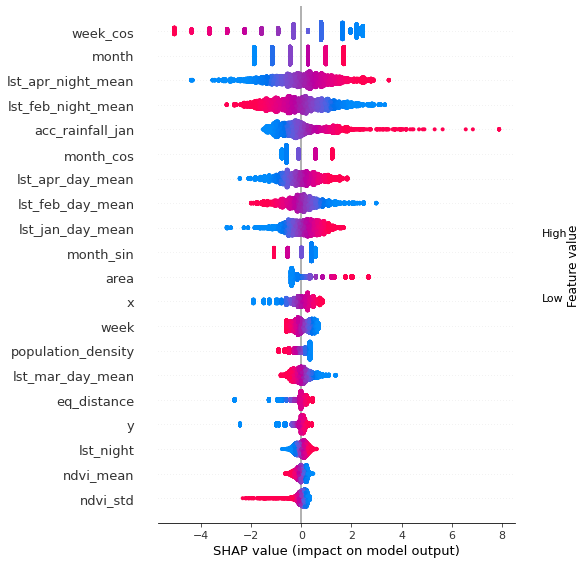

In [9]:
shap.summary_plot(shap_values, features = X_train, feature_names = features)

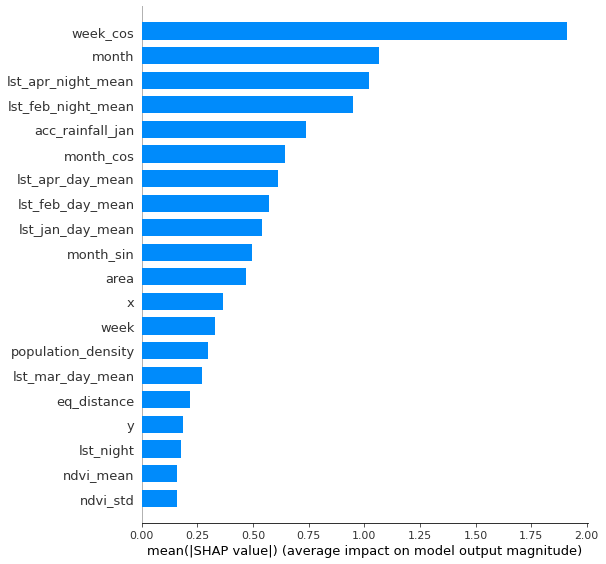

In [10]:
shap.summary_plot(shap_values, features = X_train, feature_names = features, plot_type='bar')

In [11]:
mean_shap_values = shap_values.mean(axis=0)

In [12]:
ft_importance = pd.DataFrame()

for i in range(len(features)):
    ft_importance = ft_importance.append({'Feature': features[i],
                                          'Shap': mean_shap_values[i]}, ignore_index = True)

In [13]:
ft_importance.sort_values(by='Shap', key=pd.Series.abs, inplace = True, ascending = False)

In [14]:
ft_importance

,Feature,Shap
4,month,-0.092800
12,week_cos,0.084097
32,lst_jan_day_mean,0.067893
38,lst_apr_day_mean,-0.064603
35,lst_feb_night_mean,-0.062417
1,y,-0.051129
10,month_cos,-0.050955
9,month_sin,-0.044115
16,eq_distance,-0.042782
5,week,0.027679


In [15]:
mean_shap = ft_importance['Shap']
shp = mean_shap.shape[0]
mean_shap = mean_shap.to_numpy().reshape(1,shp)

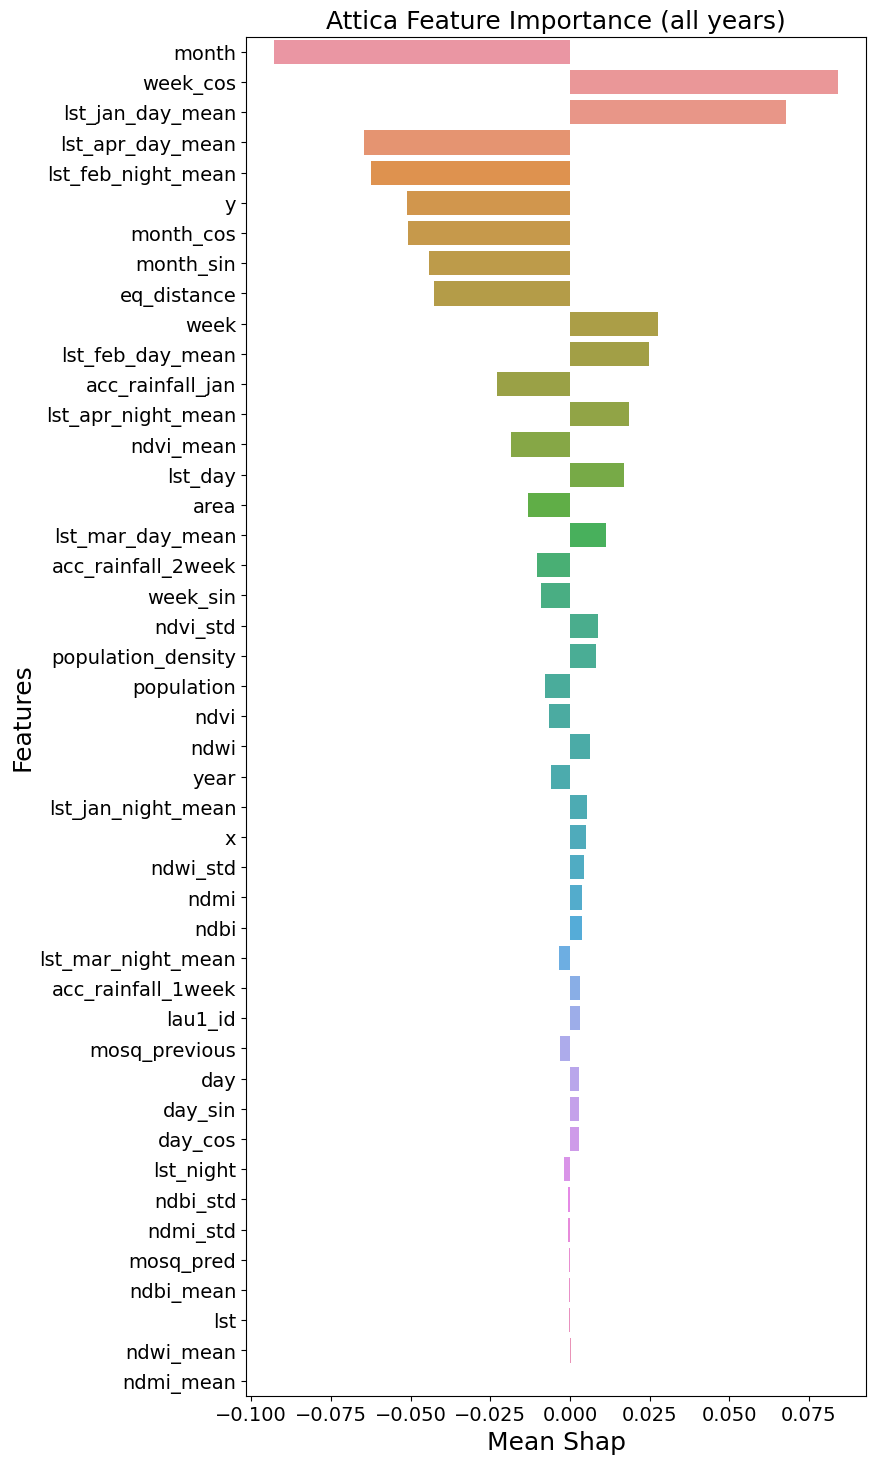

In [16]:
plot_feature_importance(mean_shap, ft_importance['Feature'], x_label = 'Mean Shap', title = f'{NUTS2} Feature Importance (all years)', title_size=18)